# 💳 Fraud Detection — SMOTE, Logistic Regression & Random Forest

**Oasis Infobyte Data Analytics — Level 2, Task 3**

This notebook is organised exactly as **Code → Visual → Interpretation** for each major analysis. The graph produced by each visualisation cell appears immediately below that code cell, followed by its written interpretation.


## 1. 📥 Load, Clean and Inspect the Dataset

**Question:** How imbalanced is the fraud dataset, and are duplicate transactions present?


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from imblearn.over_sampling import SMOTE

DATA_PATH = '../data/creditcard.csv'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
original_shape = df.shape
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

print('Original dataset shape:', original_shape)
print('Duplicate rows removed:', duplicate_count)
print('Cleaned dataset shape:', df.shape)
print('Class counts:')
print(df['Class'].value_counts())
print(f'Fraud percentage: {df["Class"].mean()*100:.4f}%')


Original dataset shape: (284807, 31)
Duplicate rows removed: 1081
Cleaned dataset shape: (283726, 31)
Class counts:
Class
0    283253
1       473
Name: count, dtype: int64
Fraud percentage: 0.1667%


### 🔎 Interpretation

The dataset originally contains **284,807 transactions**. After removing **1,081 duplicate rows**, the cleaned dataset contains **283,726 transactions**, including **473 fraudulent transactions (0.1667%)**. Fraud is therefore extremely rare, making class imbalance a central modelling challenge.


## 2. 📊 Class Distribution

**Question:** How severe is the imbalance between legitimate and fraudulent transactions?


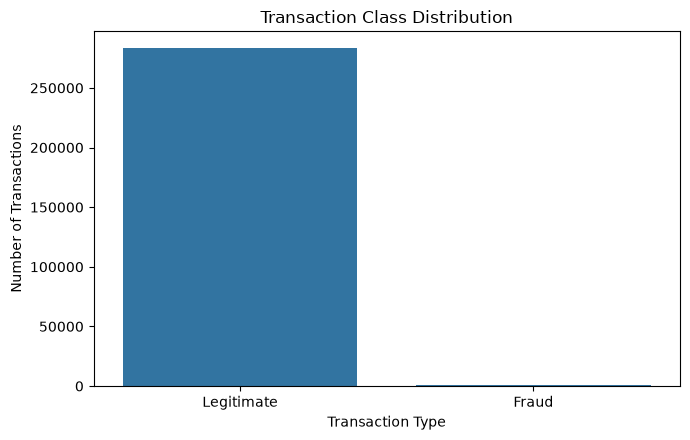

In [2]:
class_counts = df['Class'].value_counts().sort_index()
labels = ['Legitimate', 'Fraud']

plt.figure(figsize=(7, 4.5))
sns.barplot(x=labels, y=class_counts.values)
plt.title('Transaction Class Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution.png'), dpi=160, bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution.svg'), bbox_inches='tight')
plt.show()


### 🔎 Interpretation

The graph shows an **extreme class imbalance**: legitimate transactions overwhelmingly outnumber fraudulent transactions. A model could appear highly accurate by predicting almost every transaction as legitimate while missing most fraud. Therefore, accuracy alone is not an appropriate primary metric.


## 3. ⚠️ Why Standard Accuracy Is Misleading

With fraud representing only about **0.17%** of the cleaned transactions, a model that predicted every transaction as legitimate would still achieve roughly **99.83% accuracy** while detecting **0% of fraud**. For this reason, the project focuses on **Precision, Recall, F1-score and ROC-AUC**.


## 4. 💳 Transaction Amount Analysis

**Question:** Do fraudulent transactions have a different transaction-amount distribution from legitimate transactions?

Because transaction amounts are highly skewed, the chart uses `log(1 + Amount)` for clearer comparison.


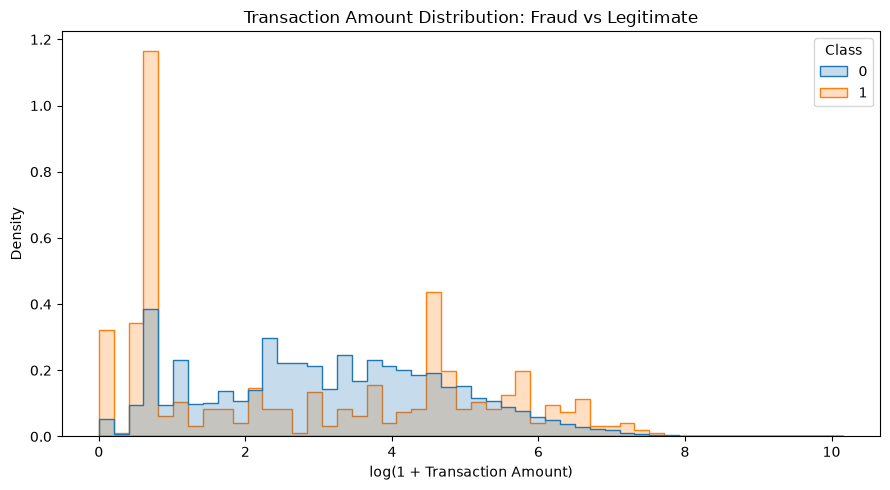

In [3]:
amount_eda = df[['Amount', 'Class']].copy()
amount_eda['AmountLog'] = np.log1p(amount_eda['Amount'])

plt.figure(figsize=(9, 5))
sns.histplot(
    data=amount_eda,
    x='AmountLog',
    hue='Class',
    bins=50,
    element='step',
    stat='density',
    common_norm=False
)
plt.title('Transaction Amount Distribution: Fraud vs Legitimate')
plt.xlabel('log(1 + Transaction Amount)')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'amount_distribution.png'), dpi=160, bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_DIR, 'amount_distribution.svg'), bbox_inches='tight')
plt.show()


### 🔎 Interpretation

The two distributions overlap substantially, showing that **transaction amount alone cannot reliably distinguish fraud from legitimate activity**. In the cleaned data, the median legitimate transaction amount is **R22.00**, while the median fraudulent amount is **R9.25**. This supports combining `Amount` with the anonymised transaction features.


## 5. 🕐 Relative Time-of-Day Analysis

**Question:** Does the fraud rate change across the dataset's 24-hour cycle?

The `Time` column records elapsed seconds from the first transaction, so this is a **relative** hour rather than a real-world clock time.


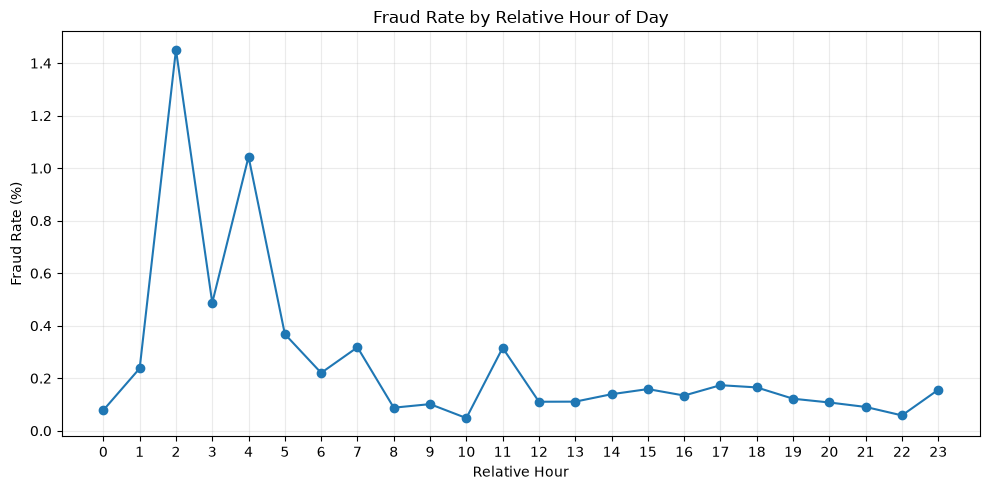

In [4]:
time_eda = df[['Time', 'Class']].copy()
time_eda['Hour'] = ((time_eda['Time'] / 3600) % 24).astype(int)

hourly = (
    time_eda.groupby('Hour')['Class']
    .agg(['count', 'sum'])
    .rename(columns={'count': 'Transactions', 'sum': 'Fraud'})
)
hourly['FraudRatePct'] = hourly['Fraud'] / hourly['Transactions'] * 100

plt.figure(figsize=(10, 5))
plt.plot(hourly.index, hourly['FraudRatePct'], marker='o')
plt.xticks(range(24))
plt.title('Fraud Rate by Relative Hour of Day')
plt.xlabel('Relative Hour')
plt.ylabel('Fraud Rate (%)')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fraud_rate_by_hour.png'), dpi=160, bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_DIR, 'fraud_rate_by_hour.svg'), bbox_inches='tight')
plt.show()


### 🔎 Interpretation

The fraud rate varies across the relative 24-hour cycle rather than remaining perfectly constant. This provides useful exploratory signal, but the `Time` feature is **not a real-world timestamp**, so the pattern should not be interpreted as a specific day/night or business-hour effect.


## 6. ⚖️ Stratified Train/Test Split and SMOTE

**Question:** How can we handle severe class imbalance without leaking information from the test set into training?


In [5]:
X = df.drop(columns='Class')
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

smote = SMOTE(random_state=42, sampling_strategy=0.10)
X_smote, y_smote = smote.fit_resample(X_train_s, y_train)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', y_smote.value_counts().to_dict())


Train shape: (226980, 30)
Test shape: (56746, 30)
Before SMOTE: {0: 226602, 1: 378}
After SMOTE: {0: 226602, 1: 22660}


### 🔎 Interpretation

The split is **stratified**, so fraud remains represented in both training and testing sets. `StandardScaler` is fitted only on training data, and **SMOTE is applied only to the training data**. The test set therefore remains untouched and representative of the original class imbalance, preventing test-set leakage.


## 7. 🤖 Model Training and Comparison

**Question:** Which performs better: Logistic Regression or Random Forest?


In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=20,
        max_depth=16,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    )
}

metrics = []
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_smote, y_smote)
    pred = model.predict(X_test_s)
    prob = model.predict_proba(X_test_s)[:, 1]
    predictions[name] = pred
    probabilities[name] = prob
    metrics.append({
        'Model': name,
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, prob)
    })

metrics_df = pd.DataFrame(metrics)
display(metrics_df.style.format({
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1': '{:.2%}',
    'ROC-AUC': '{:.2%}'
}))
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'model_metrics.csv'), index=False)


,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,40.00%,80.00%,53.33%,96.64%
1,Random Forest,92.31%,75.79%,83.24%,96.72%


### 🔎 Interpretation

**Random Forest is the strongest overall model in this experiment.** It balances precision and recall much better than Logistic Regression. Logistic Regression is useful as a high-recall baseline, while Random Forest produces substantially fewer false-positive alerts.


## 8. 🧩 Confusion Matrices

**Question:** How many legitimate and fraudulent transactions does each model classify correctly or incorrectly?


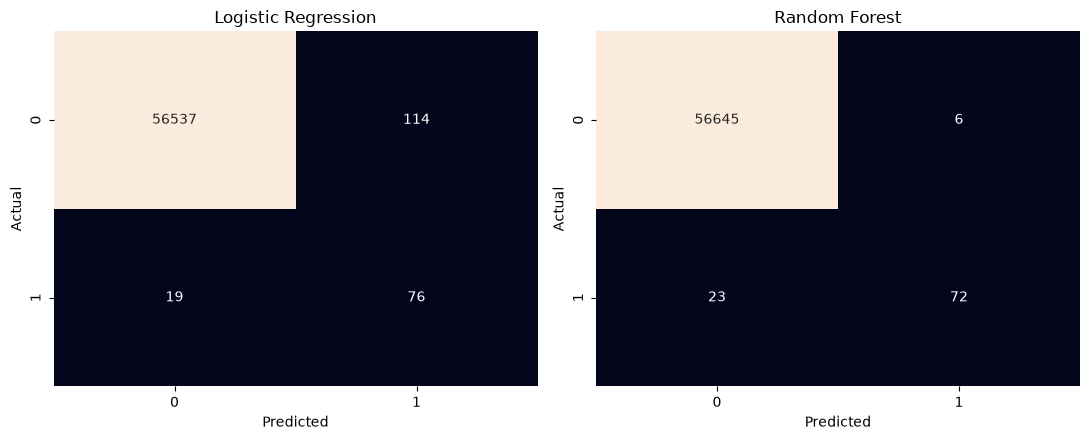

Logistic Regression
[[56537   114]
 [   19    76]]
Random Forest
[[56645     6]
 [   23    72]]


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.png'), dpi=160, bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.svg'), bbox_inches='tight')
plt.show()

for name, pred in predictions.items():
    print(name)
    print(confusion_matrix(y_test, pred))


### 🔎 Interpretation

The confusion matrices make the **recall versus false-positive trade-off** visible. Logistic Regression is configured to catch slightly more fraudulent transactions, while Random Forest substantially reduces false-positive alerts. This is why Random Forest achieves the stronger precision and F1 balance.


## 9. 📈 ROC Curve

**Question:** How well can each model separate fraudulent from legitimate transactions across different classification thresholds?


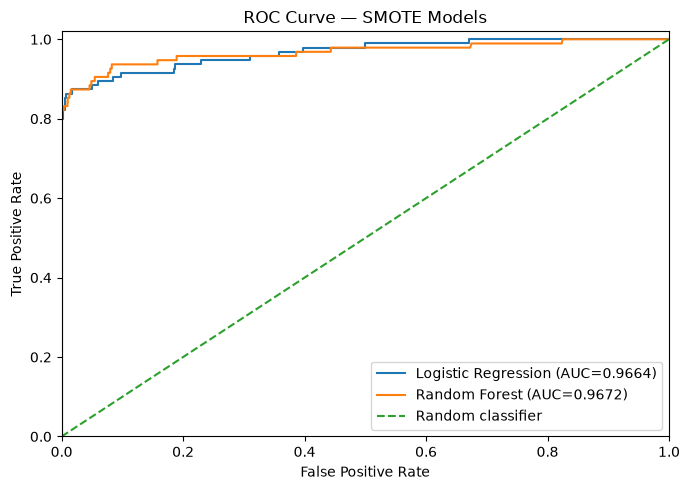

In [8]:
plt.figure(figsize=(7, 5))

for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], '--', label='Random classifier')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SMOTE Models')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve.png'), dpi=160, bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve.svg'), bbox_inches='tight')
plt.show()


### 🔎 Interpretation

Both models perform far better than random classification. The model with the higher ROC-AUC provides stronger overall ranking performance across classification thresholds. The curve is especially useful here because fraud detection involves choosing a threshold that balances missed fraud against false alerts.


## 10. 🎯 Precision vs Recall Trade-off

**Question:** Which metric matters most in fraud detection?

**Recall** matters because missing a fraudulent transaction can cause financial loss. **Precision** matters because excessive false positives create unnecessary investigations and can inconvenience legitimate customers.

In this project, the best model should therefore not simply maximise recall. It should achieve a practical balance between **Recall, Precision and F1-score**, with the final threshold selected according to the business cost of missed fraud versus false alerts.


## 11. 🔎 Random Forest Feature Importance

**Question:** Which anonymised features contribute most strongly to the Random Forest's predictions?


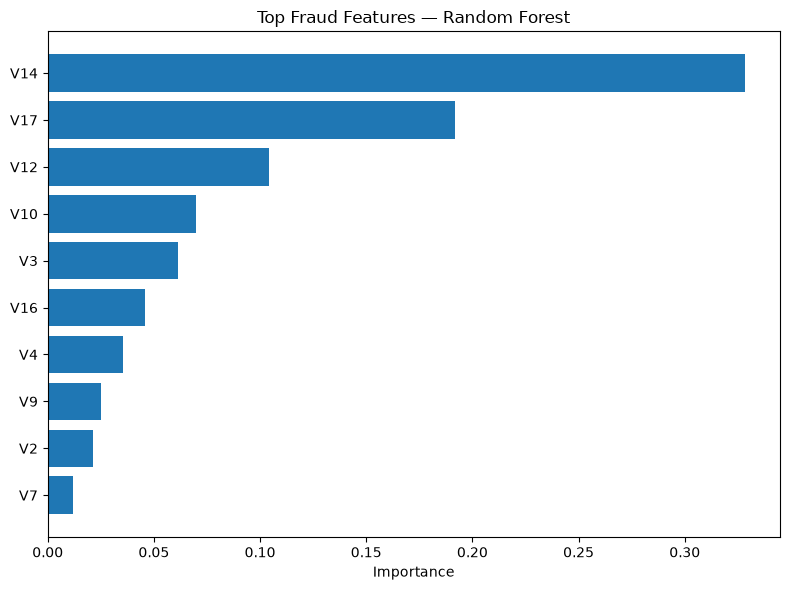

In [9]:
rf = models['Random Forest']

importance = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf.feature_importances_
    })
    .sort_values('Importance', ascending=False)
)

importance.to_csv(
    os.path.join(RESULTS_DIR, 'random_forest_feature_importance.csv'),
    index=False
)

top = importance.head(10).sort_values('Importance')

plt.figure(figsize=(8, 6))
plt.barh(top['Feature'], top['Importance'])
plt.xlabel('Importance')
plt.title('Top Fraud Features — Random Forest')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'feature_importance.png'), dpi=160, bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_DIR, 'feature_importance.svg'), bbox_inches='tight')
plt.show()


### 🔎 Interpretation

The most influential variables are anonymised PCA-derived `V` features. Their importance indicates predictive signal, but they cannot be interpreted as direct business variables such as customer demographics or merchant categories because the original feature meanings were anonymised.


## 12. 🚀 Scalability — 1 Million Transactions per Hour

**Question:** Can this approach support a high-volume production environment?

**1,000,000 transactions/hour ≈ 277.8 transactions/second.**

A production implementation should use streaming or micro-batched ingestion, efficient feature generation, parallel stateless scoring workers, load balancing, autoscaling, latency monitoring, data-quality checks, fraud-rate/model-drift monitoring, threshold management and periodic retraining. Production capacity should be validated with load testing rather than inferred from notebook execution time.


## ✅ Final Conclusion

This notebook demonstrates a complete fraud-detection workflow: data cleaning, class-imbalance analysis, fraud-focused EDA, stratified splitting, train-only scaling, SMOTE, Logistic Regression, Random Forest, precision/recall/F1/ROC-AUC evaluation, confusion matrices, ROC analysis, feature importance and production scalability considerations.

The notebook is intentionally organised so that each major visual follows its **code immediately**, and each visual is followed immediately by its **interpretation**.

**Execution check:** this notebook is designed to be executed from the `notebooks` directory so its relative dataset and results paths resolve correctly.
